In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model

In [2]:
diabetes = datasets.load_diabetes()
print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [3]:
print(diabetes.data)

[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]


In [4]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [5]:
diabetes_X = diabetes.data[:, np.newaxis, 2]

In [6]:
print(diabetes_X)

[[ 0.06169621]
 [-0.05147406]
 [ 0.04445121]
 [-0.01159501]
 [-0.03638469]
 [-0.04069594]
 [-0.04716281]
 [-0.00189471]
 [ 0.06169621]
 [ 0.03906215]
 [-0.08380842]
 [ 0.01750591]
 [-0.02884001]
 [-0.00189471]
 [-0.02560657]
 [-0.01806189]
 [ 0.04229559]
 [ 0.01211685]
 [-0.0105172 ]
 [-0.01806189]
 [-0.05686312]
 [-0.02237314]
 [-0.00405033]
 [ 0.06061839]
 [ 0.03582872]
 [-0.01267283]
 [-0.07734155]
 [ 0.05954058]
 [-0.02129532]
 [-0.00620595]
 [ 0.04445121]
 [-0.06548562]
 [ 0.12528712]
 [-0.05039625]
 [-0.06332999]
 [-0.03099563]
 [ 0.02289497]
 [ 0.01103904]
 [ 0.07139652]
 [ 0.01427248]
 [-0.00836158]
 [-0.06764124]
 [-0.0105172 ]
 [-0.02345095]
 [ 0.06816308]
 [-0.03530688]
 [-0.01159501]
 [-0.0730303 ]
 [-0.04177375]
 [ 0.01427248]
 [-0.00728377]
 [ 0.0164281 ]
 [-0.00943939]
 [-0.01590626]
 [ 0.0250506 ]
 [-0.04931844]
 [ 0.04121778]
 [-0.06332999]
 [-0.06440781]
 [-0.02560657]
 [-0.00405033]
 [ 0.00457217]
 [-0.00728377]
 [-0.0374625 ]
 [-0.02560657]
 [-0.02452876]
 [-0.01806

In [7]:
diabetes_X_train = diabetes_X[:-30]
diabetes_X_test = diabetes_X[-20:]

In [8]:
diabetes_Y_train = diabetes.target[:-30]
diabetes_Y_test = diabetes.target[-20:]

In [9]:
model = linear_model.LinearRegression()

In [10]:
model.fit(diabetes_X_train, diabetes_Y_train)

LinearRegression()

In [11]:
model.predict(diabetes_X_test)

array([226.70014103, 116.09940303, 163.78962951, 115.08471736,
       121.17283138, 158.71620116, 236.84699773, 122.18751705,
        99.86443231, 124.21688839, 205.39174197,  96.8203753 ,
       154.65745848, 131.31968807,  83.62946159, 171.90711487,
       138.42248776, 138.42248776, 190.17145692,  84.64414726])

In [12]:
diabetes_Y_predicted = model.predict(diabetes_X_test)

In [13]:
from sklearn.metrics import mean_squared_error

In [14]:
print("Mean squared error is: ", mean_squared_error(diabetes_Y_test, diabetes_Y_predicted))

Mean squared error is:  2561.3204277283853


In [15]:
print("Weights: ", model.coef_)
print("Intercept: ", model.intercept_)

Weights:  [941.43097333]
Intercept:  153.39713623331644


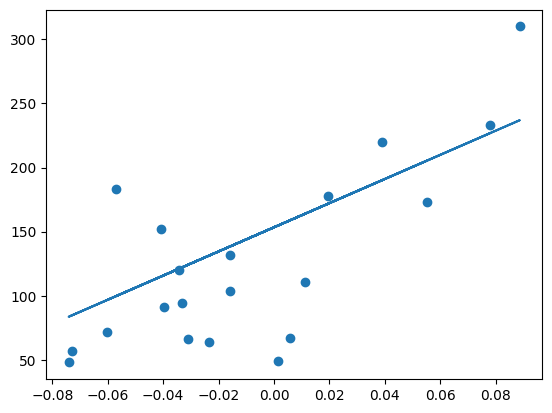

In [16]:
plt.scatter(diabetes_X_test, diabetes_Y_test)
plt.plot(diabetes_X_test, diabetes_Y_predicted)
plt.show()


--- Ridge Regression ---
Ridge Mean squared error is:  3168.585674804528
Ridge Weights:  [612.64202818]
Ridge Intercept:  153.43475612599627

--- Cross-Validation Scores (R-squared) ---
Linear Regression Cross-validation R-squared scores:  [0.20669771 0.37001525 0.38937267 0.29361018 0.36254055]
Linear Regression Mean R-squared: 0.32 (+/- 0.13)
Ridge Regression Cross-validation R-squared scores:  [0.17237797 0.30099411 0.31393061 0.25961532 0.31094664]
Ridge Regression Mean R-squared: 0.27 (+/- 0.11)


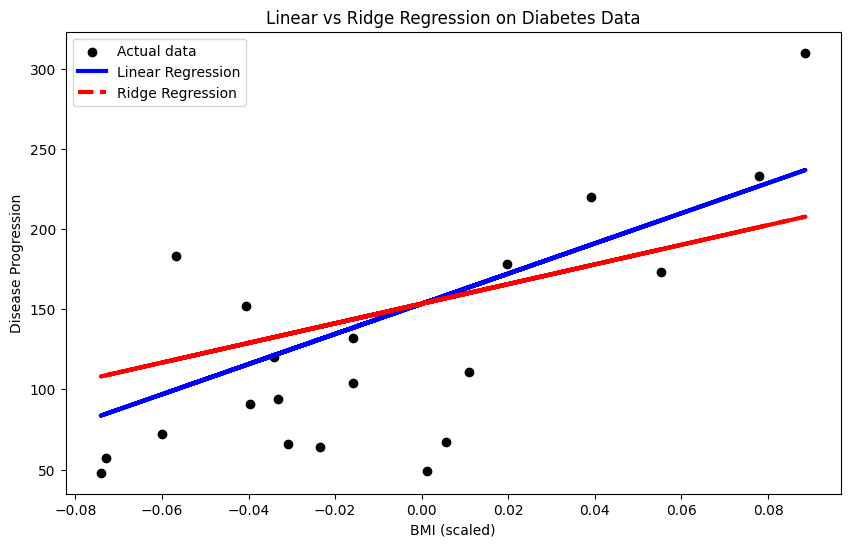

In [17]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

print("\n--- Ridge Regression ---")
ridge_model = Ridge(alpha=0.5)
ridge_model.fit(diabetes_X_train, diabetes_Y_train)

ridge_Y_predicted = ridge_model.predict(diabetes_X_test)
print("Ridge Mean squared error is: ", mean_squared_error(diabetes_Y_test, ridge_Y_predicted))
print("Ridge Weights: ", ridge_model.coef_)
print("Ridge Intercept: ", ridge_model.intercept_)

print("\n--- Cross-Validation Scores (R-squared) ---")

lr_scores = cross_val_score(model, diabetes_X, diabetes.target, cv=5)
print("Linear Regression Cross-validation R-squared scores: ", lr_scores)
print("Linear Regression Mean R-squared: %.2f (+/- %.2f)" % (lr_scores.mean(), lr_scores.std() * 2))

ridge_scores = cross_val_score(ridge_model, diabetes_X, diabetes.target, cv=5)
print("Ridge Regression Cross-validation R-squared scores: ", ridge_scores)
print("Ridge Regression Mean R-squared: %.2f (+/- %.2f)" % (ridge_scores.mean(), ridge_scores.std() * 2))

plt.figure(figsize=(10, 6))
plt.scatter(diabetes_X_test, diabetes_Y_test, color='black', label='Actual data')
plt.plot(diabetes_X_test, diabetes_Y_predicted, color='blue', linewidth=3, label='Linear Regression')
plt.plot(diabetes_X_test, ridge_Y_predicted, color='red', linestyle='--', linewidth=3, label='Ridge Regression')
plt.xlabel('BMI (scaled)')
plt.ylabel('Disease Progression')
plt.title('Linear vs Ridge Regression on Diabetes Data')
plt.legend()
plt.show()